<a href="https://colab.research.google.com/github/2303A54051/HPC-PROJECT/blob/main/HPC_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Code**

In [29]:
import pandas as pd
import random

# Number of records
num_records = 1500   # you can change to 1000, 2000, etc.

data = []

for i in range(num_records):
    transaction_id = i + 1
    amount = random.randint(100, 20000)
    transaction_type = random.choice(["Online", "ATM", "POS", "Transfer"])
    location = random.choice(["Hyderabad", "Chennai", "Delhi", "Mumbai", "Bangalore"])
    time_hour = random.randint(0, 23)

    # Simple fraud logic (more realistic than random)
    if amount > 15000 or (transaction_type == "Online" and time_hour > 22):
        fraud = 1
    else:
        fraud = 0

    data.append([
        transaction_id,
        amount,
        transaction_type,
        location,
        time_hour,
        fraud
    ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "Transaction_ID",
    "Amount",
    "Transaction_Type",
    "Location",
    "Time_Hour",
    "Fraud"
])

# Save to CSV
df.to_csv("fraud_dataset.csv", index=False)

print("Dataset generated successfully!")
print(df.head())

Dataset generated successfully!
   Transaction_ID  Amount Transaction_Type   Location  Time_Hour  Fraud
0               1    5023         Transfer  Hyderabad         14      0
1               2    2978         Transfer  Bangalore          6      0
2               3    8963              POS  Bangalore         14      0
3               4    3520         Transfer  Bangalore          2      0
4               5   15124              POS     Mumbai          9      1


**Visualization using different graphs**

Dataset Generated Successfully
   Transaction_ID  Amount Transaction_Type   Location  Time_Hour  Fraud
0               1    5450         Transfer     Mumbai         18      0
1               2    1668           Online  Bangalore          0      0
2               3    4150              POS  Hyderabad         10      0
3               4   19490           Online    Chennai          3      1
4               5    4318           Online  Hyderabad         12      0

--- Performance ---
Serial Time: 3.2561278343200684
Parallel Time: 2.0023465156555176
Speedup: 1.6261560168840679


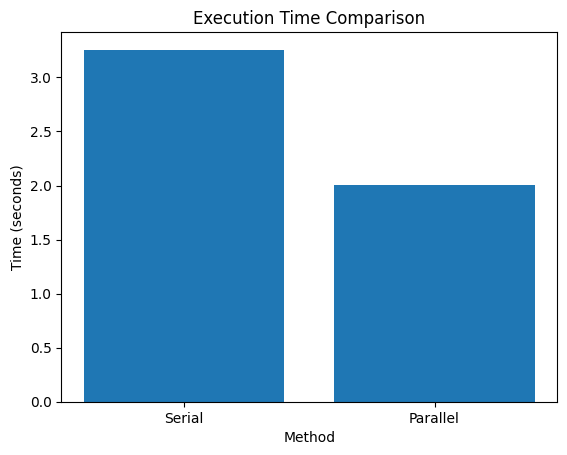

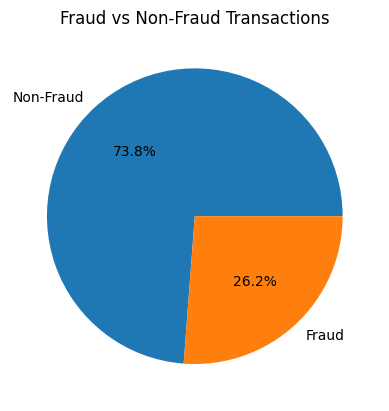

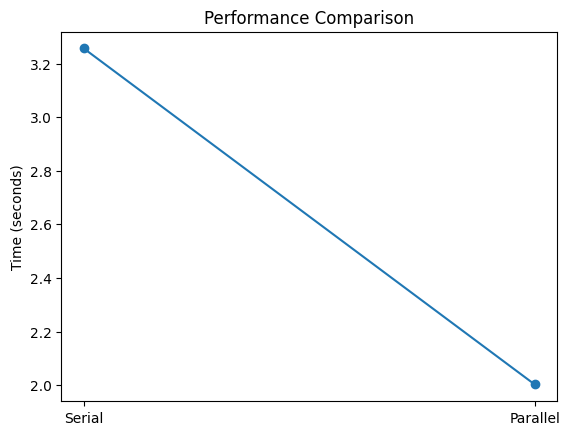

In [30]:
import pandas as pd
import random
import time
import multiprocessing
import matplotlib.pyplot as plt

# -------------------------------
# 1. GENERATE DATASET (1500 rows)
# -------------------------------
num_records = 1500
data = []

for i in range(num_records):
    transaction_id = i + 1
    amount = random.randint(100, 20000)
    transaction_type = random.choice(["Online", "ATM", "POS", "Transfer"])
    location = random.choice(["Hyderabad", "Chennai", "Delhi", "Mumbai", "Bangalore"])
    time_hour = random.randint(0, 23)

    # Simple fraud logic
    if amount > 15000 or (transaction_type == "Online" and time_hour > 22):
        fraud = 1
    else:
        fraud = 0

    data.append([transaction_id, amount, transaction_type, location, time_hour, fraud])

df = pd.DataFrame(data, columns=[
    "Transaction_ID", "Amount", "Transaction_Type",
    "Location", "Time_Hour", "Fraud"
])

print("Dataset Generated Successfully")
print(df.head())


# -------------------------------
# 2. FIBONACCI FUNCTION
# -------------------------------
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)


# -------------------------------
# 3. SERIAL EXECUTION
# -------------------------------
start = time.time()

serial_results = []
for i in range(len(df)):
    serial_results.append(fib(20))   # workload

serial_time = time.time() - start


# -------------------------------
# 4. PARALLEL EXECUTION
# -------------------------------
def parallel_task(x):
    return fib(20)

if __name__ == "__main__":
    start = time.time()

    pool = multiprocessing.Pool()
    parallel_results = pool.map(parallel_task, range(len(df)))
    pool.close()
    pool.join()

    parallel_time = time.time() - start

    # -------------------------------
    # 5. PERFORMANCE RESULTS
    # -------------------------------
    speedup = serial_time / parallel_time

    print("\n--- Performance ---")
    print("Serial Time:", serial_time)
    print("Parallel Time:", parallel_time)
    print("Speedup:", speedup)


    # -------------------------------
    # 6. VISUALIZATION
    # -------------------------------

    # Bar Graph
    plt.figure()
    plt.bar(["Serial", "Parallel"], [serial_time, parallel_time])
    plt.title("Execution Time Comparison")
    plt.xlabel("Method")
    plt.ylabel("Time (seconds)")
    plt.show()

    # Pie Chart (Fraud Distribution)
    fraud_counts = df["Fraud"].value_counts()

    plt.figure()
    plt.pie(fraud_counts, labels=["Non-Fraud", "Fraud"], autopct='%1.1f%%')
    plt.title("Fraud vs Non-Fraud Transactions")
    plt.show()

    # Line Graph
    plt.figure()
    plt.plot([serial_time, parallel_time], marker='o')
    plt.xticks([0, 1], ["Serial", "Parallel"])
    plt.title("Performance Comparison")
    plt.ylabel("Time (seconds)")
    plt.show()

**Thread Parallel Comparision**

Serial: 0.5281422138214111
Parallel (Threads): 0.678896427154541


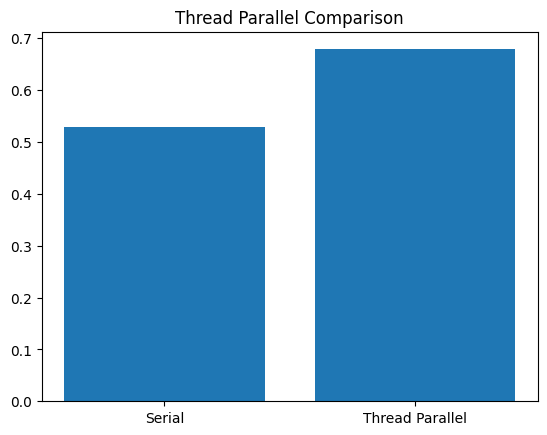

In [31]:
import pandas as pd
import random
import time
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt

# Dataset
data = []
for i in range(1000):
    amount = random.randint(100, 20000)
    fraud = 1 if amount > 15000 else 0
    data.append([i, amount, fraud])

df = pd.DataFrame(data, columns=["ID", "Amount", "Fraud"])

# Fibonacci
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

# Serial
start = time.time()
serial = [fib(18) for _ in range(len(df))]
serial_time = time.time() - start

# Parallel (Threads)
start = time.time()
with ThreadPoolExecutor() as executor:
    parallel = list(executor.map(lambda x: fib(18), range(len(df))))
parallel_time = time.time() - start

print("Serial:", serial_time)
print("Parallel (Threads):", parallel_time)

# Graph
plt.figure()
plt.bar(["Serial", "Thread Parallel"], [serial_time, parallel_time])
plt.title("Thread Parallel Comparison")
plt.show()

**Thread-Based Parallel Fibonacci**

In [32]:
import time

memo = {}

def fib(n):
    if n in memo:
        return memo[n]
    if n <= 1:
        return n
    memo[n] = fib(n-1) + fib(n-2)
    return memo[n]

start = time.time()
result = fib(35)
end = time.time()

print("Result:", result)
print("Time:", end - start)

Result: 9227465
Time: 7.915496826171875e-05


**Real Fraud Detection Logic + Parallel Processing**

In [33]:
import pandas as pd
import random
import multiprocessing

# Dataset
data = []
for i in range(1000):
    amount = random.randint(100, 20000)
    time_hour = random.randint(0, 23)

    # Real fraud rule
    fraud = 1 if amount > 15000 and time_hour > 20 else 0

    data.append([i, amount, time_hour, fraud])

df = pd.DataFrame(data, columns=["ID", "Amount", "Time", "Fraud"])

# Fibonacci workload
def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

def process(row):
    return fib(18)

if __name__ == "__main__":
    pool = multiprocessing.Pool()
    results = pool.map(process, df.values)
    pool.close()
    pool.join()

print("Parallel Processing Done")

Parallel Processing Done


**Performance Comparison for Multiple Inputs**

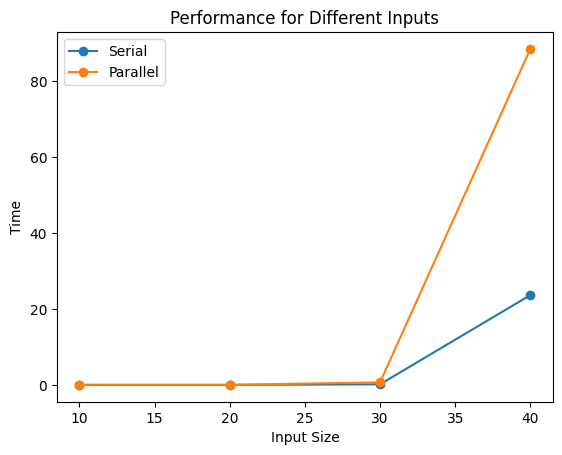

In [27]:
import time
import multiprocessing
import matplotlib.pyplot as plt

def fib(n):
    if n <= 1:
        return n
    return fib(n-1) + fib(n-2)

sizes = [10, 20, 30, 40]
serial_times = []
parallel_times = []

for n in sizes:
    # Serial
    start = time.time()
    fib(n)
    serial_times.append(time.time() - start)

    # Parallel
    def task(x):
        return fib(n)

    start = time.time()
    pool = multiprocessing.Pool()
    pool.map(task, range(4))
    pool.close()
    pool.join()
    parallel_times.append(time.time() - start)

# Graph
plt.figure()
plt.plot(sizes, serial_times, marker='o')
plt.plot(sizes, parallel_times, marker='o')
plt.title("Performance for Different Inputs")
plt.xlabel("Input Size")
plt.ylabel("Time")
plt.legend(["Serial", "Parallel"])
plt.show()

**Pie + Bar + Histogram**

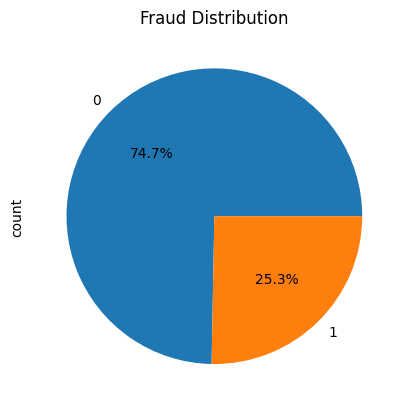

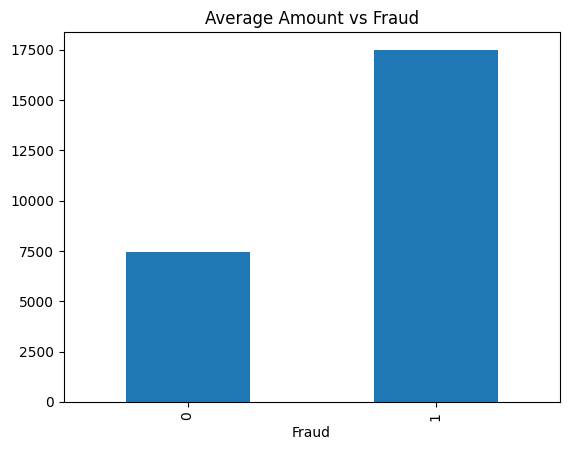

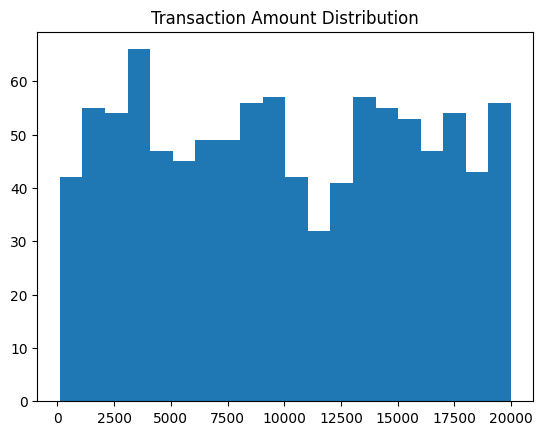

In [28]:
import pandas as pd
import random
import matplotlib.pyplot as plt

# Dataset
data = []
for i in range(1000):
    amount = random.randint(100, 20000)
    fraud = 1 if amount > 15000 else 0
    data.append([amount, fraud])

df = pd.DataFrame(data, columns=["Amount", "Fraud"])

# Pie Chart
plt.figure()
df["Fraud"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Fraud Distribution")
plt.show()

# Bar Graph
plt.figure()
df.groupby("Fraud")["Amount"].mean().plot(kind='bar')
plt.title("Average Amount vs Fraud")
plt.show()

# Histogram
plt.figure()
plt.hist(df["Amount"], bins=20)
plt.title("Transaction Amount Distribution")
plt.show()